In [1]:
from pathlib import Path
from astropy.table import Table
import glob
import os
import numpy as np
import pandas as pd

from datetime import datetime, timedelta
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec


In [2]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = (3.5,3)
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 400
plt.rcParams['axes.linewidth'] = 1.1
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['font.family'] = 'DeJavu Serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['text.usetex'] = False
plt.rcParams['mathtext.fontset'] = 'dejavuserif'
plt.rcParams['mathtext.rm'] = 'Times New Roman'

In [3]:
%config InlineBackend.figure_format = 'svg'

## Cumulative LST-1 observation time

In [4]:
source_catalog = Table.read("/fefs/onsite/data/lst-pipe/LSTN-01/OSA/Catalog/LST_source_catalog.ecsv")

In [5]:
all_dates = pd.Series(source_catalog["Date directory"]).unique()

In [6]:
len(all_dates)

830

In [7]:
time_hours = []

for date in all_dates:
    date_catalog = source_catalog[source_catalog["Date directory"]==date]
    time_min = sum(date_catalog["Elapsed [min]"])
    time_hours.append(time_min/60)

df = pd.DataFrame()
df["Date"] = all_dates
df["Observing_time"] = time_hours

Text(0.5, 0, 'Date')

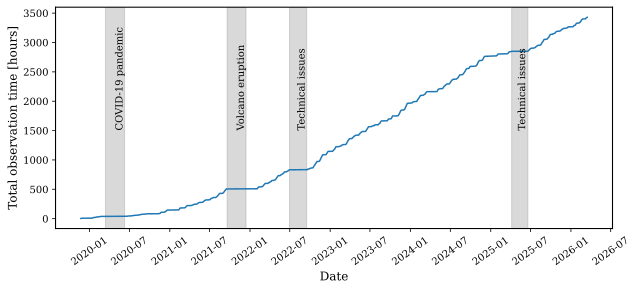

In [8]:
dates = [datetime.strptime(d, "%Y-%m-%d") for d in all_dates]

cumulative_hours = np.cumsum(time_hours)

fig = plt.figure(figsize=(10,4))
ax = fig.add_subplot(111)
ax.plot(dates, cumulative_hours)

ax.axvspan(datetime(2020, 3, 14), datetime(2020, 6, 9), color='gray', alpha=0.3)
ax.text(datetime(2020, 6, 9), 1500, 'COVID-19 pandemic', rotation=90, 
        verticalalignment='bottom', horizontalalignment='right', color='k')

ax.axvspan(datetime(2021, 9, 19), datetime(2021, 12, 14), color='gray', alpha=0.3)
ax.text(datetime(2021, 12, 14), 1500, 'Volcano eruption', rotation=90, 
        verticalalignment='bottom', horizontalalignment='right', color='k')

ax.axvspan(datetime(2022, 6, 30), datetime(2022, 9, 16), color='gray', alpha=0.3)
ax.text(datetime(2022, 9, 16), 1500, 'Technical issues', rotation=90, 
        verticalalignment='bottom', horizontalalignment='right', color='k')

ax.axvspan(datetime(2025, 4, 6), datetime(2025, 6, 19), color='gray', alpha=0.3)
ax.text(datetime(2025, 6, 16), 1500, 'Technical issues', rotation=90, 
        verticalalignment='bottom', horizontalalignment='right', color='k')

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 7)))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))


plt.xticks(rotation=35)

ax.set_ylabel("Total observation time [hours]")
ax.set_xlabel("Date")

#fig.savefig("figures/observing_time.pdf", facecolor='white', bbox_inches = "tight", transparent=False)

## lstosa completion times

In [9]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/fefs/onsite/data/lst-pipe/LSTN-01/OSA/database/osa.db") 
cursor = conn.cursor()

df = pd.read_sql_query("SELECT * FROM processing ORDER BY date ASC", conn)
df

,telescope,date,prod_id,start,end,is_finished
0,LST1,2020-02-05,v0.11_crab,2026-04-16 09:30:17.628505,None,0
1,LST1,2020-02-11,v0.11_crab,2026-04-09 15:22:46.145703,None,0
2,LST1,2020-02-12,v0.11_crab,2026-04-09 15:22:56.436773,None,0
3,LST1,2020-03-01,v0.11_crab,2026-04-14 18:27:00.374667,None,0
4,LST1,2020-03-04,v0.11_crab,2026-04-14 19:12:39.018814,None,0
...,...,...,...,...,...,...
1355,LST1,2026-04-09,v0.11,2026-04-10 08:26:40.488476,None,0
1356,LST1,2026-04-15,v0.11,2026-04-16 08:58:34.053999,None,0
1357,LST1,2026-04-16,v0.11,2026-04-17 08:25:34.501790,None,0
1358,LST1,2026-04-20,v0.11,2026-04-21 08:25:41.988746,None,0


In [10]:
# remove dates with no information in the db:

new_df = pd.DataFrame()
empty_df = []

for date in all_dates:
    df_date = df[df["date"]==date]
    if len(df_date)==0:
        empty_df.append(date)
    new_df = pd.concat([new_df, df_date])

    
# remove dates not processed with prod_id v0.9, v0.10 or v0.11:

mask = (new_df["prod_id"]=="v0.9") | (new_df["prod_id"]=="v0.10") | (new_df["prod_id"]=="v0.11") 
new_df = new_df[mask]
new_df = new_df[~pd.isnull(new_df["end"])]


# remove dates for which the next-day processing finished with more than one day of delay:

for i in new_df.index:
    date_dir = datetime.fromisoformat(new_df.loc[i,"date"]).date()
    processing_date = datetime.strptime(new_df.loc[i,"end"], "%Y-%m-%d %H:%M:%S.%f").date()
    if date_dir + timedelta(days=1) < processing_date:
        new_df = new_df.drop(i)

In [11]:
end_times = [datetime.strptime(d, "%Y-%m-%d %H:%M:%S.%f").time() for d in new_df["end"]]
end_time = [t.hour + t.minute / 60 + t.second / 3600 for t in end_times]

Text(0, 0.5, 'Processed nights (%)')

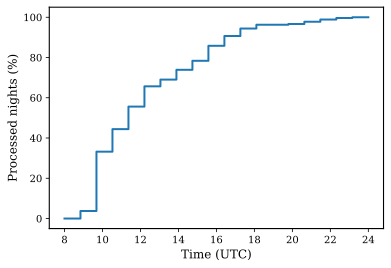

In [12]:
fig = plt.figure(figsize=(6,4))
ax = fig.add_subplot(111)

x_times = np.linspace(8, 24, 20)
percentages = [(np.sum(np.array(end_time) <= t+1) / len(end_time)) * 100 for t in x_times]

ax.step(x_times, percentages, where="post", linewidth=2)
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Processed nights (%)")


In [13]:
dates_2025 = new_df[(new_df["date"]>"2025") & (new_df["date"]<"2025-06-25")]
dates_2024 = new_df[(new_df["date"]>"2024") & (new_df["date"]<"2025")]
dates_2023 = new_df[(new_df["date"]>"2023") & (new_df["date"]<"2024")]
dates_2022 = new_df[(new_df["date"]>"2022") & (new_df["date"]<"2023")]
dates_2021 = new_df[(new_df["date"]>"2021") & (new_df["date"]<"2022")]
dates_2020 = new_df[(new_df["date"]>"2020") & (new_df["date"]<"2021")]

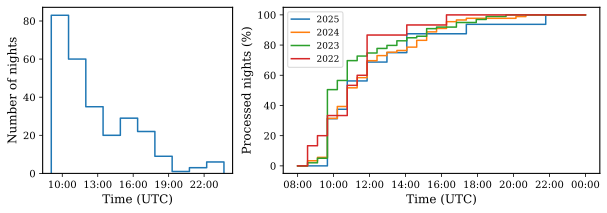

In [14]:
end_times = [datetime.strptime(d, "%Y-%m-%d %H:%M:%S.%f").time() for d in dates_2025["end"]]
end_time_2025 = [t.hour + t.minute / 60 + t.second / 3600 for t in end_times]

end_times = [datetime.strptime(d, "%Y-%m-%d %H:%M:%S.%f").time() for d in dates_2024["end"]]
end_time_2024 = [t.hour + t.minute / 60 + t.second / 3600 for t in end_times]

end_times = [datetime.strptime(d, "%Y-%m-%d %H:%M:%S.%f").time() for d in dates_2023["end"]]
end_time_2023 = [t.hour + t.minute / 60 + t.second / 3600 for t in end_times]

end_times = [datetime.strptime(d, "%Y-%m-%d %H:%M:%S.%f").time() for d in dates_2022["end"]]
end_time_2022 = [t.hour + t.minute / 60 + t.second / 3600 for t in end_times]


fig = plt.figure(figsize=(10,3))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 2])

ax = fig.add_subplot(gs[0])
base_date = datetime(2025, 7, 18)
x_datetimes = [base_date + timedelta(hours=hour) for hour in end_time]
ax.hist(x_datetimes, histtype="step", linewidth=1.5)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3)) 
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Number of nights")

        
ax = fig.add_subplot(gs[1])

x_times = np.linspace(8, 24, 30)
base_date = datetime(2025, 7, 18)
x_datetimes = [base_date + timedelta(hours=hour) for hour in x_times]

percentages_2025 = [(np.sum(np.array(end_time_2025) <= t+1) / len(end_time_2025)) * 100 for t in x_times]
percentages_2024 = [(np.sum(np.array(end_time_2024) <= t+1) / len(end_time_2024)) * 100 for t in x_times]
percentages_2023 = [(np.sum(np.array(end_time_2023) <= t+1) / len(end_time_2023)) * 100 for t in x_times]
percentages_2022 = [(np.sum(np.array(end_time_2022) <= t+1) / len(end_time_2022)) * 100 for t in x_times]

ax.step(x_datetimes, percentages_2025, where="post", linewidth=1.5, label="2025")
ax.step(x_datetimes, percentages_2024, where="post", linewidth=1.5, label="2024")
ax.step(x_datetimes, percentages_2023, where="post", linewidth=1.5, label="2023")
ax.step(x_datetimes, percentages_2022, where="post", linewidth=1.5, label="2022")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Processed nights (%)")
ax.legend()

#fig.savefig("figures/lstosa_end_time.pdf", facecolor='white', bbox_inches = "tight", transparent=False)

## Gain selection completion times

In [15]:
gainsel_flag_files = glob.glob("/fefs/onsite/data/lst-pipe/LSTN-01/OSA/GainSel/2025????/GainSelFinished.txt")
gainsel_flag_files = gainsel_flag_files + glob.glob("/fefs/aswg/data/real/OSA/GainSel/202?????/GainSelFinished.txt")

In [16]:
gainsel_flag_files = sorted(gainsel_flag_files)

In [17]:
gainsel_end_times = []
for file in gainsel_flag_files:
    mtime = os.path.getmtime(file)
    dt = datetime.fromtimestamp(mtime)
    gainsel_end_times.append(dt)

Text(0, 0.5, 'Processed nights')

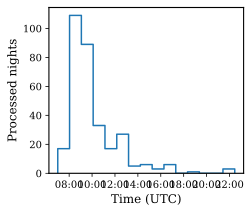

In [18]:
end_times = [d.time() for d in gainsel_end_times]

base_date = datetime(2025, 1, 1)
datetime_list = [datetime.combine(base_date, t) for t in end_times]

fig, ax = plt.subplots()
ax.hist(datetime_list, bins=15, histtype="step", linewidth=1.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Processed nights")

Text(0, 0.5, 'Processed nights (%)')

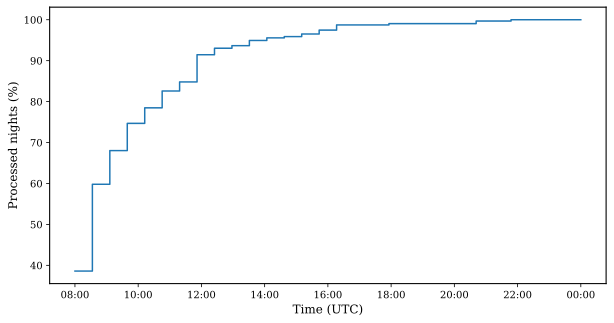

In [19]:
end_times = [d.time() for d in gainsel_end_times]
end_time = [t.hour + t.minute / 60 + t.second / 3600 for t in end_times]

x_times = np.linspace(8, 24, 30)
base_date = datetime(2025, 7, 18)
x_datetimes = [base_date + timedelta(hours=hour) for hour in x_times]

percentages = [(np.sum(np.array(end_time) <= t+1) / len(end_time)) * 100 for t in x_times]

fig = plt.figure(figsize=(10,5))
ax = fig.add_subplot(111)

ax.step(x_datetimes, percentages, where='post', linewidth=1.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Processed nights (%)")


Text(0, 0.5, 'Processed nights (%)')

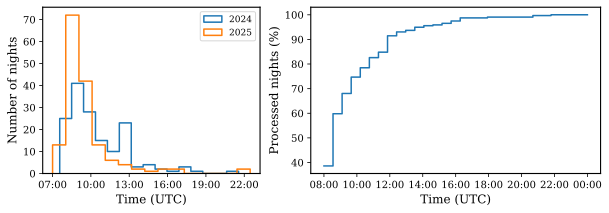

In [20]:
gainsel_flag_files_2024 = [i for i in gainsel_flag_files if "2024" in i]
gainsel_flag_files_2025 = [i for i in gainsel_flag_files if "2025" in i]

gainsel_end_times_2024 = []
gainsel_end_times_2025 = []
for file in gainsel_flag_files_2024:
    mtime = os.path.getmtime(file)
    dt = datetime.fromtimestamp(mtime)
    gainsel_end_times_2024.append(dt)
    
for file in gainsel_flag_files_2025:
    mtime = os.path.getmtime(file)
    dt = datetime.fromtimestamp(mtime)
    gainsel_end_times_2025.append(dt)
    
end_times_2024 = [d.time() for d in gainsel_end_times_2024]
end_times_2025 = [d.time() for d in gainsel_end_times_2025]

base_date = datetime(2025, 1, 1)
datetime_list_2024 = [datetime.combine(base_date, t) for t in end_times_2024]
datetime_list_2025 = [datetime.combine(base_date, t) for t in end_times_2025]

fig = plt.figure(figsize=(10,3))
gs = gridspec.GridSpec(1, 2, width_ratios=[1.5, 2])

ax = fig.add_subplot(gs[0])
ax.hist(datetime_list_2024, bins=15, histtype='step', linewidth=1.5, label="2024")
ax.hist(datetime_list_2025, bins=15, histtype='step', linewidth=1.5, label="2025")

# Format x-axis to show time
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=3))
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Number of nights")
ax.legend()


ax = fig.add_subplot(gs[1])
ax.step(x_datetimes, percentages, where='post', linewidth=1.5)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Processed nights (%)")

#fig.savefig("figures/gainsel_end_time.pdf", facecolor='white', bbox_inches = "tight", transparent=False)

## Data volume reduction

In [21]:
df = pd.read_csv("data_volume_reduction_summary.csv")
df = df.set_index("Unnamed: 0")
df.index.name = None

In [22]:
df

,Original total size (TB),Final total size (TB),% of original total size,Total gained size (TB),R0 data size (TB),R0G data size (TB),% of original data size,R0V total size (TB),R0V data size (TB),% of original total size (R0V),% of original data size (R0V)
202007,47.75,33.73,71%,14.02,34.22,20.20,59%,5.161072,2.937062,10.808528,8.582881
202008,48.33,32.03,66%,16.30,40.90,24.60,60%,10.467773,3.737695,21.658956,9.138619
202009,95.60,85.25,89%,10.35,26.49,16.15,61%,25.600497,2.213964,26.778763,8.357735
202010,1.31,0.81,62%,0.50,1.23,0.73,59%,0.190689,0.133576,14.556423,10.859799
202011,78.52,50.67,65%,27.85,68.63,40.79,59%,14.746851,8.069097,18.781012,11.757391
202012,78.04,57.62,74%,20.42,68.44,48.01,70%,15.828430,9.124231,20.282458,13.331723
202101,12.93,12.46,96%,0.47,1.18,0.72,61%,4.114442,0.158518,31.820896,13.433736
202102,69.99,48.86,70%,21.13,53.09,31.95,60%,10.794247,7.345368,15.422557,13.835690
202103,103.92,68.40,66%,35.52,88.17,52.65,60%,19.136236,10.962574,18.414392,12.433451
202104,66.66,43.41,65%,23.25,57.47,34.22,60%,9.555158,6.273998,14.334171,10.916997


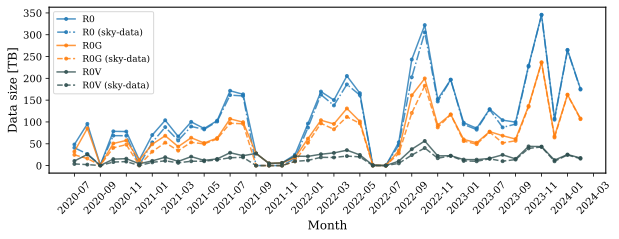

In [23]:
fig = plt.figure(figsize=(10,3))
ax = fig.add_subplot(111)

df = df.copy()
df = df[df.index != "Total"]
dates = pd.to_datetime(df.index, format='%Y%m')

ax.plot(df.index[1:-1], df["Original total size (TB)"][1:-1], marker='.', alpha=0.8, c="tab:blue", label="R0")
ax.plot(df.index[1:-1], df["R0 data size (TB)"][1:-1], ls="-.", marker='.', alpha=0.8, c="tab:blue", label="R0 (sky-data)")
ax.plot(df.index[1:-1], df["Final total size (TB)"][1:-1], marker='.', alpha=0.8, c="tab:orange", label="R0G")
ax.plot(df.index[1:-1], df["R0G data size (TB)"][1:-1], ls="--", marker='.', alpha=0.8, c="tab:orange", label="R0G (sky-data)")
ax.plot(df.index[1:-1], df["R0V total size (TB)"][1:-1], marker='.', alpha=0.8, c="darkslategrey", label="R0V")
ax.plot(df.index[1:-1], df["R0V data size (TB)"][1:-1], ls="--", marker='.', alpha=0.8, c="darkslategrey", label="R0V (sky-data)")

ax.set_ylabel("Data size [TB]")

step = 2  # or 3
tick_positions = list(range(0, len(df), step))
tick_labels = dates.strftime('%Y-%m')[::step]

ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, rotation=45)

ax.set_xlabel("Month")
ax.legend()

#fig.savefig("figures/dvr_reduction.pdf", facecolor='white', bbox_inches = "tight", transparent=False)